In [1]:
import sys
sys.path.append('..')
import torch
from torchvision import transforms
from PIL import Image
import glob
import base64
import matplotlib.pyplot as plt
import io

from tools.gradcam_tool import explain_gradcam

print("imports done")

imports done


In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

images = glob.glob("../data/HAM10000_images_part_1/*.jpg")
test_image = transform(Image.open(images[0]).convert("RGB")).unsqueeze(0)
print("image loaded:", images[0])

image loaded: ../data/HAM10000_images_part_1\ISIC_0024306.jpg


In [3]:
result = explain_gradcam(test_image, pred_class=0)
print("status:          ", result['status'])
print("attention region:", result['attention_region'])
print("interpretation:  ", result['interpretation'])

status:           error
attention region: unknown
interpretation:   Grad-CAM analysis failed


In [4]:
# display the overlay plot
img_data = base64.b64decode(result['plot_b64'])
img = Image.open(io.BytesIO(img_data))
plt.figure(figsize=(13, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x000001A8A9072070>

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

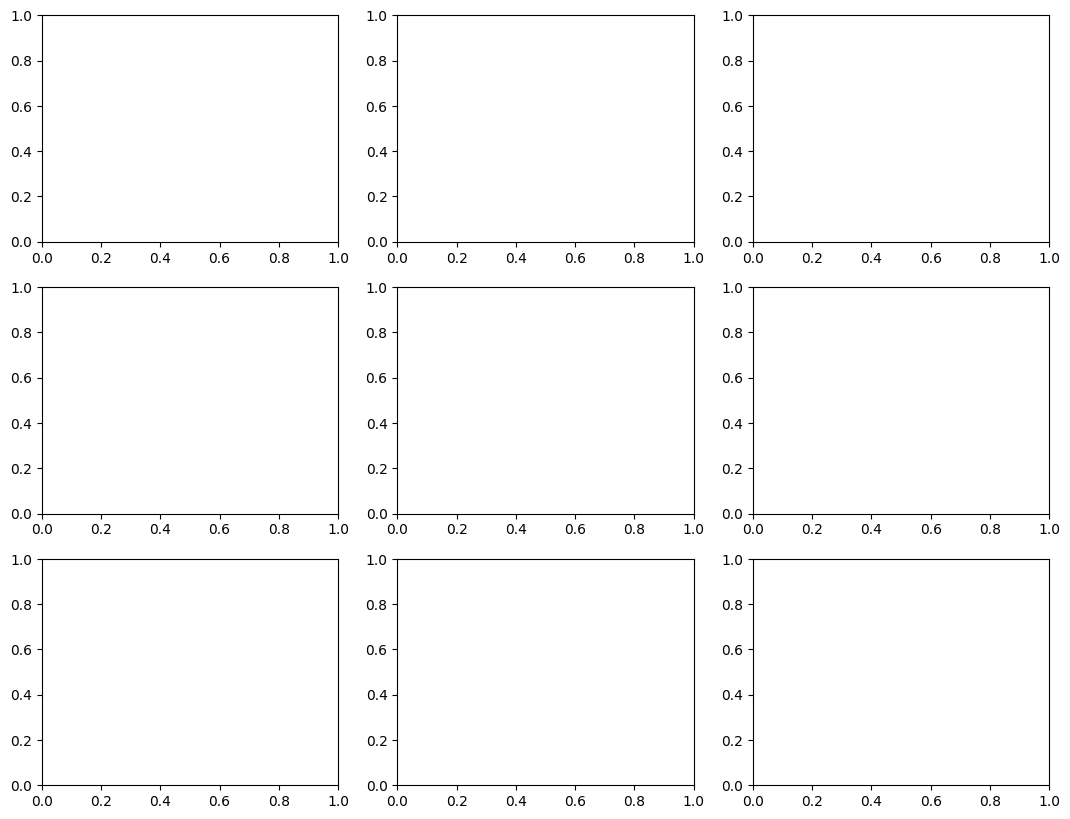

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))

for row, img_path in enumerate(images[1:4]):
    img_tensor = transform(Image.open(img_path).convert("RGB")).unsqueeze(0)
    res = explain_gradcam(img_tensor, pred_class=0)

    orig = img_tensor[0].permute(1, 2, 0).numpy()
    orig = (orig * 0.5 + 0.5).clip(0, 1)

    import numpy as np
    import matplotlib.cm as cm
    cam = np.array(res['heatmap'])
    heatmap = cm.jet(cam)[:, :, :3]
    overlay = (0.55 * orig + 0.45 * heatmap).clip(0, 1)

    axes[row][0].imshow(orig)
    axes[row][0].set_title("original")
    axes[row][0].axis("off")

    axes[row][1].imshow(cam, cmap='jet')
    axes[row][1].set_title("grad-cam")
    axes[row][1].axis("off")

    axes[row][2].imshow(overlay)
    axes[row][2].set_title(res['attention_region'])
    axes[row][2].axis("off")

plt.suptitle("Grad-CAM across 3 different lesion images", fontsize=13)
plt.tight_layout()
plt.show()